In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

tracking_data = pd.read_csv("results.csv")

#write name of color to analyze (yellow, green, red)
color = "green"

X_COLOR_1 = f"{color}_x1"
X_COLOR_2 = f"{color}_x2"
Y_COLOR_1 = f"{color}_y1"
Y_COLOR_2 = f"{color}_y2"
A_COLOR_1 = f"{color}_area1"
A_COLOR_2 = f"{color}_area2"
X_CENTER = "center_x"
Y_CENTER = "center_y"



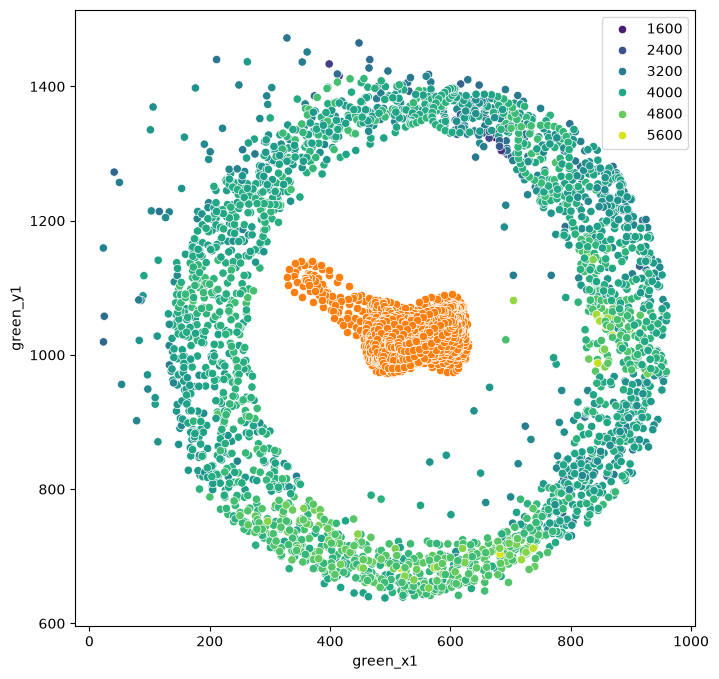

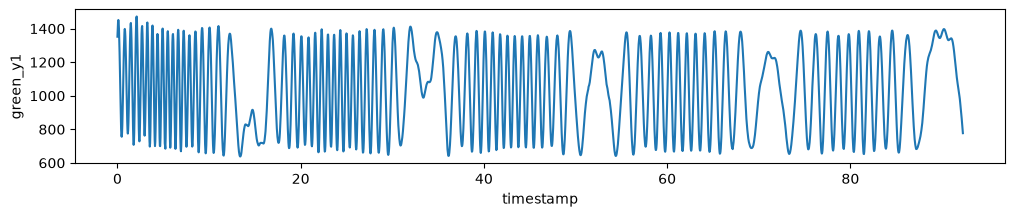

<Figure size 800x800 with 0 Axes>

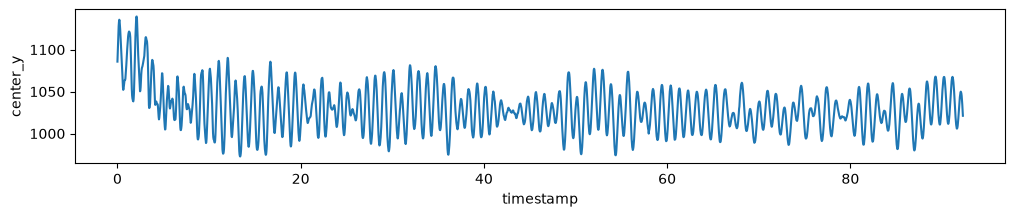

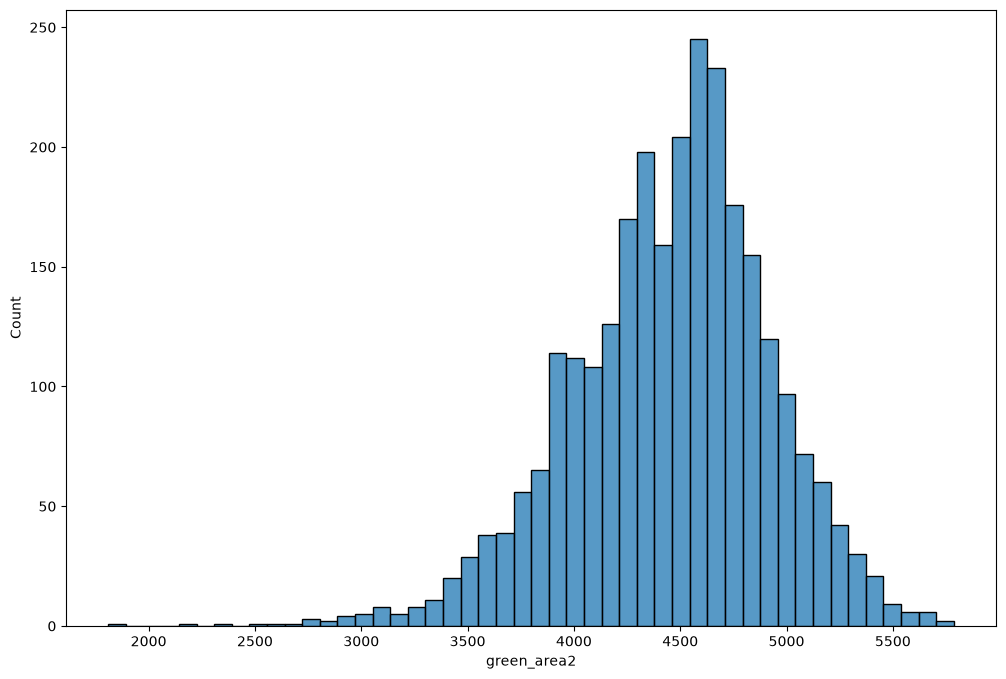

In [147]:
#Time series data

plt.figure(figsize=(8,8))
sns.scatterplot(tracking_data, x=X_COLOR_1, y=Y_COLOR_1, hue=A_COLOR_1, palette="viridis")
sns.scatterplot(tracking_data, x=X_CENTER, y=Y_CENTER)
#sns.lineplot(tracking_data, x=X_COLOR_1, y=Y_COLOR_1, lw=0.2)

plt.figure(figsize=(12,2))
sns.lineplot(tracking_data, x="timestamp", y=Y_COLOR_1)

plt.figure(figsize=(8,8))

plt.figure(figsize=(12,2))
sns.lineplot(tracking_data, x="timestamp", y=Y_CENTER)

plt.figure(figsize=(12,8))
sns.histplot(tracking_data, x=A_COLOR_2)

plt.show()

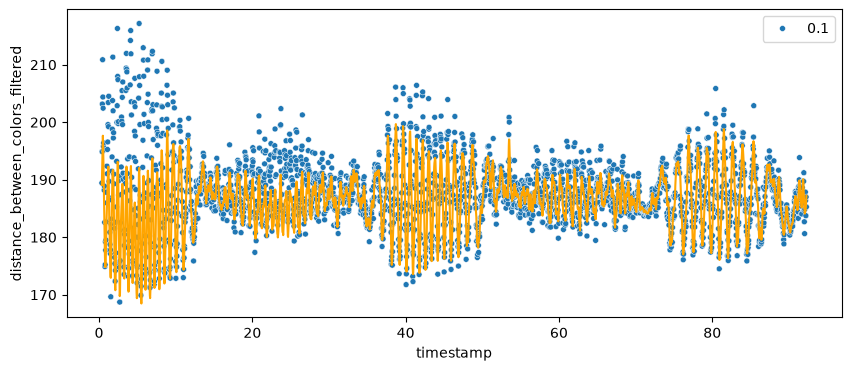

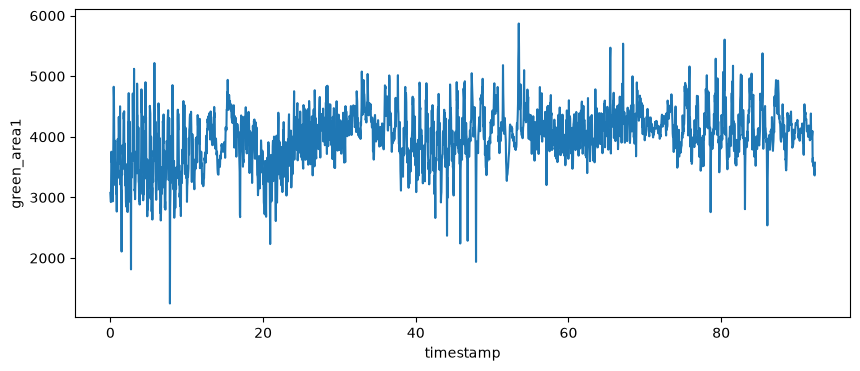

In [ ]:
# Looking at how the distance between adjacent dots changes over time
import numpy as np 
from scipy.signal import savgol_filter

#savgol hyperparams
window_size = 11
poly_order = 2
dt = np.mean(np.diff(tracking_data["timestamp"]))

tracking_data["X_COLOR_1_Filtered"] = pd.Series(savgol_filter(
    tracking_data[X_COLOR_1].interpolate(method="polynomial", order=2).to_numpy(),
    window_length=window_size,
    polyorder=poly_order,
    delta=dt
    )
)

tracking_data["X_COLOR_2_Filtered"] = pd.Series(savgol_filter(
    tracking_data[X_COLOR_2].interpolate(method="polynomial", order=2).to_numpy(),
    window_length=window_size,
    polyorder=poly_order,
    delta=dt
    )
)

tracking_data["Y_COLOR_1_Filtered"] = pd.Series(savgol_filter(
    tracking_data[Y_COLOR_1].interpolate(method="polynomial", order=2).to_numpy(),
    window_length=window_size,
    polyorder=poly_order,
    delta=dt
    )
)

tracking_data["Y_COLOR_2_Filtered"] = pd.Series(savgol_filter(
    tracking_data[Y_COLOR_2].interpolate(method="polynomial", order=2).to_numpy(),
    window_length=window_size,
    polyorder=poly_order,
    delta=dt
    )
)


tracking_data["distance_between_colors_filtered"] = np.hypot(
    abs(tracking_data["X_COLOR_1_Filtered"] - tracking_data["X_COLOR_2_Filtered"]),
    abs(tracking_data["Y_COLOR_1_Filtered"] - tracking_data["Y_COLOR_2_Filtered"])
)

tracking_data["distance_between_colors_raw"] = np.hypot(
    abs(tracking_data[X_COLOR_1] - tracking_data[X_COLOR_2]),
    abs(tracking_data[Y_COLOR_1] - tracking_data[Y_COLOR_2])
)

plt.figure(figsize=(10, 4))
sns.lineplot(tracking_data[10:], x="timestamp", y="distance_between_colors_filtered", color="orange")
sns.scatterplot(tracking_data[10:], x="timestamp", y="distance_between_colors_raw", size=0.1)

plt.figure(figsize=(10, 4))
sns.lineplot(tracking_data[:], x="timestamp", y=A_COLOR_1)

plt.show()


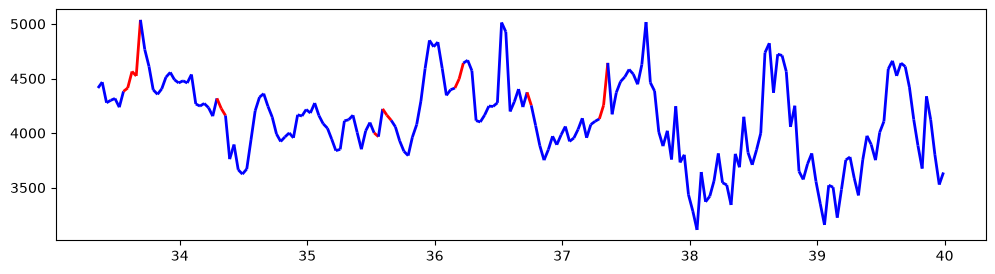

In [33]:
#Looking at whether area fluctuations are due to lighting or clipping with the edge

from matplotlib.collections import LineCollection

x = tracking_data["timestamp"].values
y = tracking_data[A_COLOR_1].values

LOWER_BOUND = 0
UPPER_BOUND = 100

tracking_data["near_edge"] = (
    (tracking_data[X_COLOR_1] > LOWER_BOUND) &
    (tracking_data[X_COLOR_1] < UPPER_BOUND)
)

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[1000:1199], points[1001:1200]], axis=1)
colors = np.where(tracking_data["near_edge"].iloc[:-1], "red", "blue")

lc = LineCollection(
    segments, # type: ignore
    colors=colors,
    linewidths=2
)

fig, ax = plt.subplots(figsize=(12,3))
ax.add_collection(lc)
ax.autoscale()

plt.show()

<Axes: xlabel='timestamp', ylabel='distance_center_filtered'>

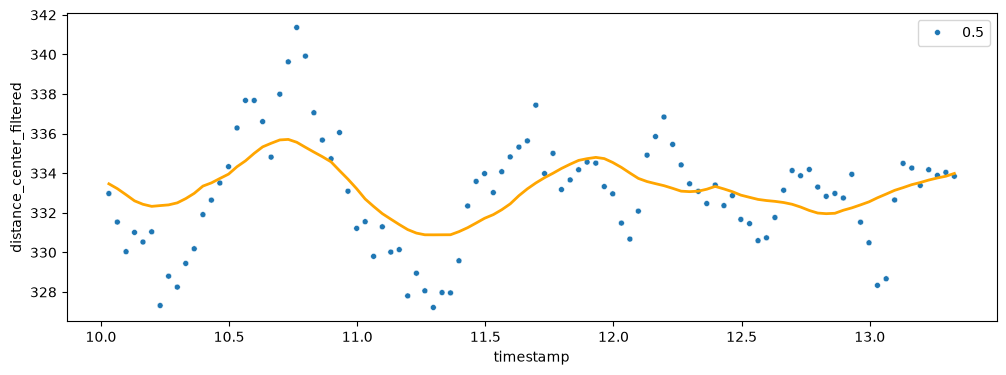

In [152]:
# Dist to Center

tracking_data["distance_center"] = np.hypot(
    abs(tracking_data[X_COLOR_1] - tracking_data[X_CENTER]),
    abs(tracking_data[Y_COLOR_1] - tracking_data[Y_CENTER])
)
distance_to_center_filtered = savgol_filter(
    tracking_data["distance_center"].to_numpy(),
    window_length=41,
    polyorder=3,
    delta=np.mean(np.diff(tracking_data["timestamp"]))
)
tracking_data["distance_center_filtered"] = pd.Series(distance_to_center_filtered)
plt.figure(figsize=(12, 4))
sns.lineplot(tracking_data[300:400], x="timestamp", y="distance_center_filtered", lw=2, color="orange")
sns.scatterplot(tracking_data[300:400], x="timestamp", y="distance_center", size=0.5)

0    37.806141
1     9.474914
2    -6.238246
3   -21.869798
4   -36.989073
Name: angle, dtype: float64
-14.832213097830117
-8.226291784630423
-8.183567202752773
-7.9153761624618895


np.float64(0.03333778901734104)

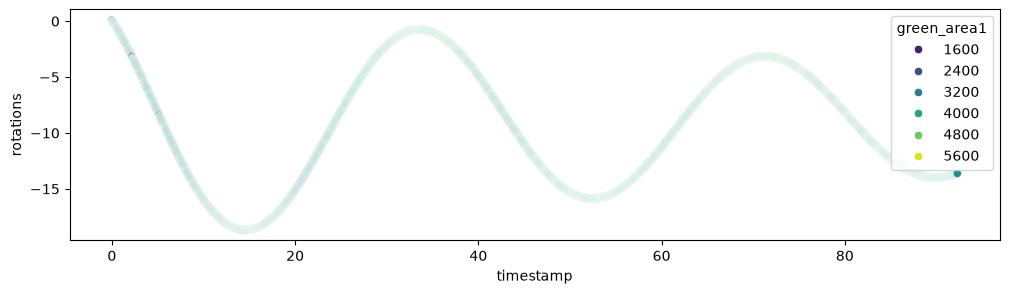

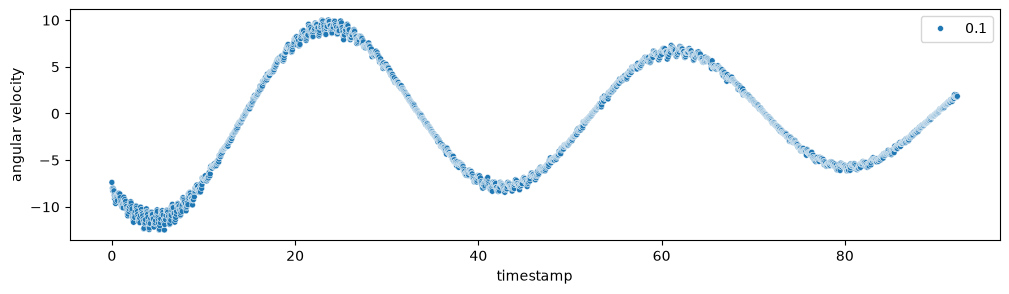

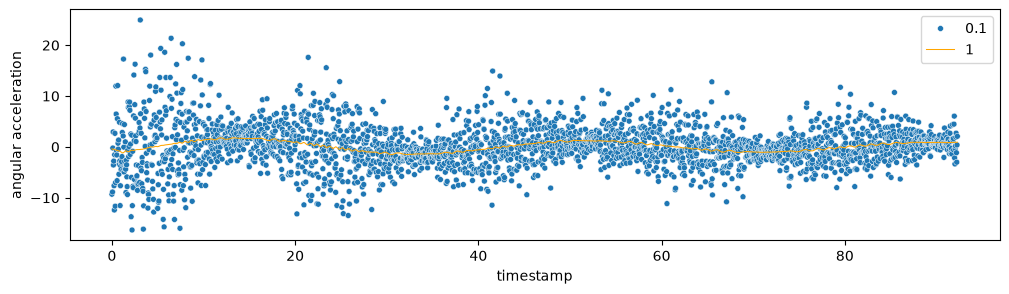

In [179]:

#Figure out why unwrapping is cutting off arbitrarily
#Plot angular velocity vs angular acceleration

dx = tracking_data[X_COLOR_1] - tracking_data[X_CENTER]
dy = tracking_data[Y_COLOR_1] - tracking_data[Y_CENTER]

dx.interpolate(inplace=True)
dy.interpolate(inplace=True)

angle = np.unwrap(np.arctan2(dx, dy))

dt = np.mean(np.diff(tracking_data["timestamp"]))

tracking_data["angle"] = np.degrees(angle)
tracking_data["angular velocity"] = np.gradient((angle), tracking_data["timestamp"])
tracking_data["angular acceleration"] = np.gradient(tracking_data["angular velocity"], tracking_data["timestamp"])
tracking_data["angular acceleration filtered"] = pd.Series(savgol_filter(
    angle,
    window_length=50,
    polyorder=3,
    deriv=2,
    delta=np.mean(np.diff(tracking_data["timestamp"]))
))

tracking_data["rotations"] = tracking_data["angle"] / 360.0

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="rotations", hue=A_COLOR_1, palette="viridis")

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="angular velocity", size=0.1)

#plt.figure(figsize=(12,3))
#sns.scatterplot(tracking_data[500:950], x="timestamp", y="angular velocity", size=0.6)

plt.figure(figsize=(12,3))
sns.scatterplot(tracking_data[:], x="timestamp", y="angular acceleration", size=0.1)
sns.lineplot(tracking_data[:], x="timestamp", y="angular acceleration filtered", size=1, color="orange")

print(tracking_data["angle"][:5])
prev_point = None
for point in angle[:5]:

    if not prev_point:
        prev_point = point
        continue

    da = point - prev_point
    derivative = da / dt

    print(derivative)
    prev_point = point

dt


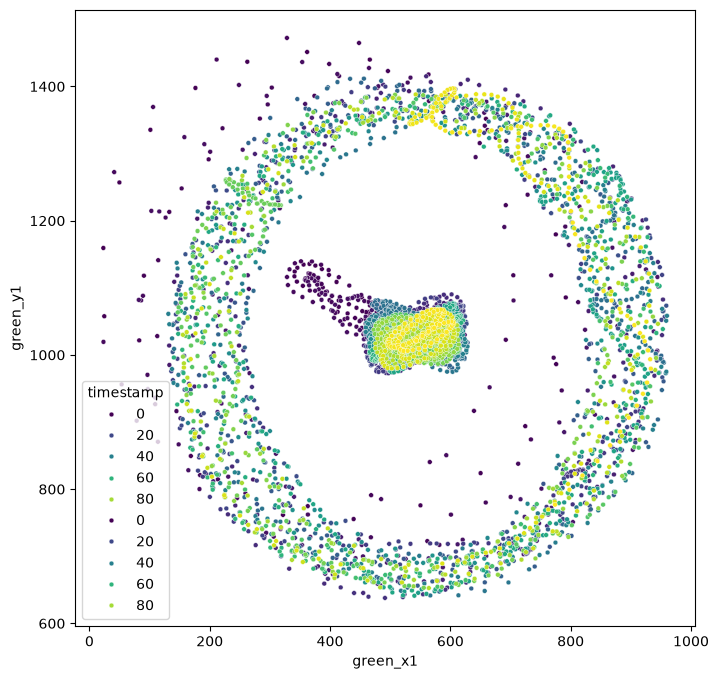

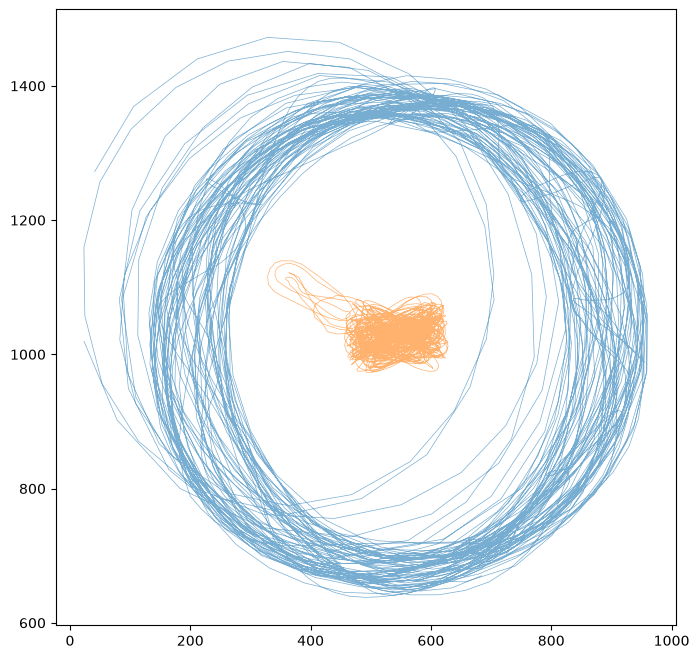

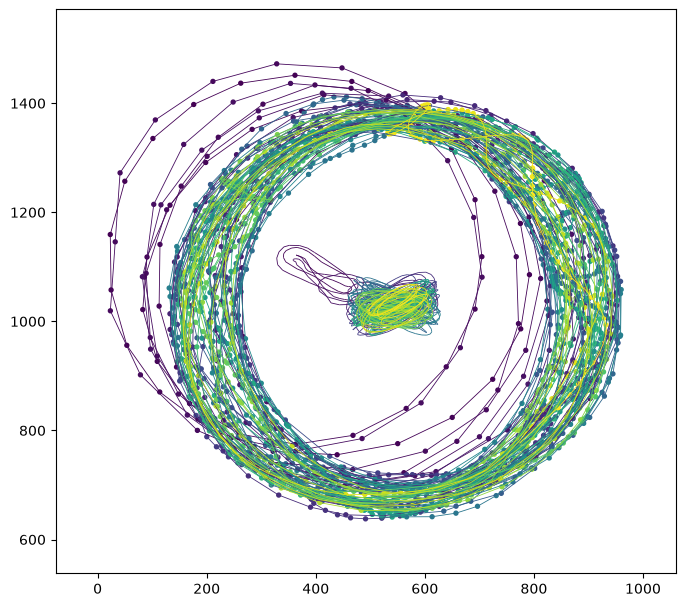

In [74]:

plt.figure(figsize=(8,8))
sns.scatterplot(
    tracking_data,
    x=X_COLOR_1,
    y=Y_COLOR_1,
    hue="timestamp",
    palette="viridis",
    s=12
)

sns.scatterplot(
    tracking_data,
    x=X_CENTER,
    y=Y_CENTER,
    hue="timestamp",
    palette="viridis",
    s=12
)

plt.figure(figsize=(8,8))
plt.plot(
    tracking_data[X_COLOR_1],
    tracking_data[Y_COLOR_1],
    lw=0.5,
    alpha=0.6
)

plt.plot(
    tracking_data[X_CENTER],
    tracking_data[Y_CENTER],
    lw=0.5,
    alpha=0.6
)

from matplotlib.colors import Normalize



x = tracking_data[X_COLOR_1].interpolate().to_numpy()
y = tracking_data[Y_COLOR_1].interpolate().to_numpy()
center_x = tracking_data[X_CENTER].interpolate().to_numpy()
center_y = tracking_data[Y_CENTER].interpolate().to_numpy()

t = tracking_data["timestamp"].to_numpy()

points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

center_points = np.array([center_x, center_y]).T.reshape(-1,1,2)
center_segments = np.concatenate([center_points[:-1], center_points[1:]], axis=1)

norm = Normalize(vmin=t.min(), vmax=t.max())
lc = LineCollection(
    segments,
    cmap="viridis",
    norm=norm,
    linewidth=0.6
)

center_lc = LineCollection(
    center_segments,
    cmap="viridis",
    norm=norm,
    linewidth=0.6
)

lc.set_array(t[:-1])
center_lc.set_array(t[:-1])

fig, ax = plt.subplots(figsize=(8, 8))
ax.add_collection(lc)
ax.add_collection(center_lc)

ax.scatter(x, y, c=t, cmap="viridis", s=8)

ax.set_xlim(x.min() - 100, x.max()+100)
ax.set_ylim(y.min() - 100, y.max()+100)
ax.set_aspect("equal")

plt.show()

<Axes: xlabel='angle', ylabel='angular acceleration filtered'>

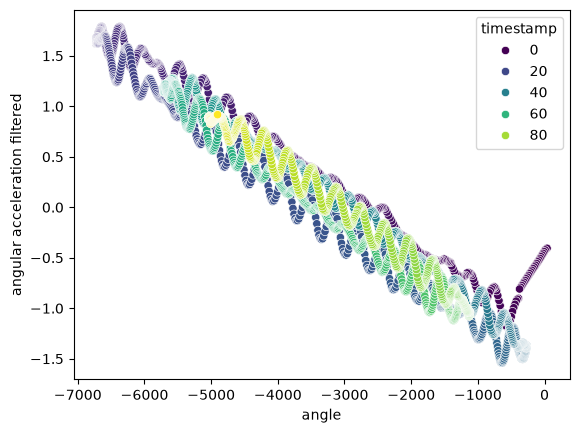

In [181]:
plt.figure()
sns.scatterplot(tracking_data[:], x="angle", y="angular acceleration filtered", hue="timestamp", palette="viridis")
